In [2]:
import numpy as np
import torch, itertools
#import utils as ut
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib import pyplot as plt
from scipy.special import gamma as gamma_func
from scipy.optimize import brentq
from utils import get_filepath
from binary_classifier import BinaryClassifier
plt.rc('axes', prop_cycle=plt.cycler(color=plt.get_cmap('Set1').colors))

In [3]:
config = {
    "data": {
        "parameter0_range": (0, 10),
        "parameter1_range": (.1, 1),
        "prior0_args": {
            "uniform": (0, 10),
            "normal": (5, 4),
            "exponential": (0.3,),
            "gamma": (2, 2),
            "sinusoidal": (5, 3)
        },
        "prior1_args": {
            "uniform": (.1, 1),
            "normal": (.55, .5),
            "exponential": (2,),
            "gamma": (2, 0.25),
            "sinusoidal": (50, 8)
        },
        "n_parameters": 2,
        "n_train": 70_000,
        "n_test": 15_000,
        "n_validation": 15_000
    },
    "classifier": {
        "n_inputs": 1,
        "n_hidden_layers": 2,
        "n_units": 64
    },
    "training": {
        "learning_rate": 0.001,
        "batch_size": 128,
        "n_epochs": 5,
        "model_iterations": 1
    }
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = np.random.default_rng(0)


#### Prior Distirbutions:

In [4]:
def normalize(function, parameter_range, fct_args):
    lower, upper = parameter_range
    x = np.linspace(lower, upper, 1000)
    integral = np.trapezoid(function(x, *fct_args), x)
    def result_fct(z): return function(z, *fct_args) / integral
    result_fct.__name__ = function.__name__
    return result_fct

def uniform(x, min_val=0, max_val=10):
    return 1 / (max_val - min_val) if min_val <= x <= max_val else 0.

def normal(x, mean=5, std=4):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))

def exponential(x, lam=.3):
    return lam * np.exp(-lam * x) if x >= 0 else 0.

def gamma(x, shape=2, scale=2):
    return (x ** (shape - 1) * np.exp(-x / scale)) / (scale ** shape * gamma_func(shape)) if x >= 0 else 0.

def sinusoidal(x, frequency=3, offset=5):
    return np.sin(frequency * x) + offset

priors = [uniform, exponential]#, normal, exponential, gamma, sinusoidal]
priors0 = [normalize(np.vectorize(f), config["data"]["parameter0_range"], config["data"]["prior0_args"][f.__name__]) for f in priors]
priors1 = [normalize(np.vectorize(f), config["data"]["parameter1_range"], config["data"]["prior1_args"][f.__name__]) for f in priors]

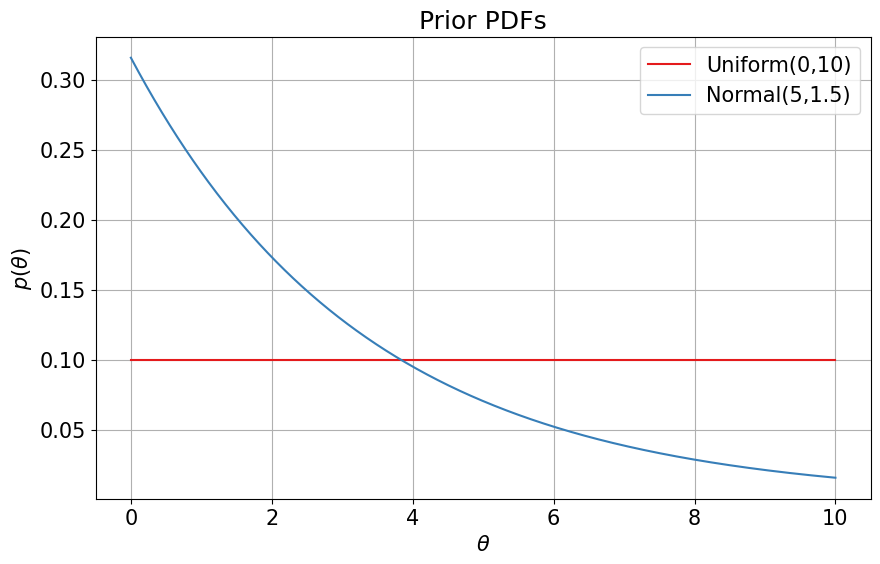

In [5]:
%matplotlib inline
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(*config["data"]["parameter0_range"], 1000)
prior0_labels = ["Uniform(0,10)", "Normal(5,1.5)", "Exponential(0.3)", "Gamma(2,2)", "Sinusoidal(5,3)"]
for prior, label in zip(priors0, prior0_labels):
    ax.plot(x, prior(x), label=label)
ax.legend()
ax.set_title("Prior PDFs")
ax.set_xlabel("$\\theta$")
ax.set_ylabel("$p(\\theta)$")
ax.grid()
fig.savefig("figs/toy_priors0.svg")
pass

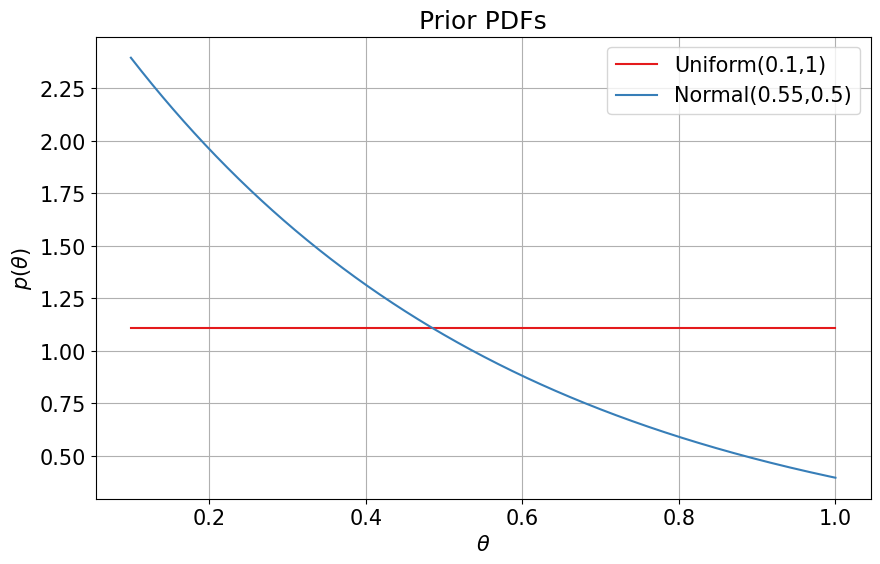

In [6]:
%matplotlib inline
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(*config["data"]["parameter1_range"], 1000)
prior1_labels = ["Uniform(0.1,1)", "Normal(0.55,0.5)", "Exponential(2)", "Gamma(2,0.2)", "Sinusoidal(50,8)"]
for prior, label in zip(priors1, prior1_labels):
    ax.plot(x, prior(x), label=label)
ax.legend()
ax.set_title("Prior PDFs")
ax.set_xlabel("$\\theta$")
ax.set_ylabel("$p(\\theta)$")
ax.grid()
fig.savefig("figs/toy_priors1.svg")

pass

In [7]:
# check normalization of priors
x1 = np.linspace(config["data"]["parameter0_range"][0], config["data"]["parameter0_range"][1], 1000)
x2 = np.linspace(config["data"]["parameter1_range"][0], config["data"]["parameter1_range"][1], 1000)
for prior in priors0:
    print(f"Integral P1 of {prior.__name__}: {np.trapezoid(prior(x1), x1)}")
for prior in priors1:
    print(f"Integral P2 of {prior.__name__}: {np.trapezoid(prior(x2), x2)}")

Integral P1 of uniform: 1.0
Integral P1 of exponential: 1.0
Integral P2 of uniform: 1.0
Integral P2 of exponential: 1.0


#### Data:

In [8]:
def sample_from_pdf(pdf, n_samples, x_min, x_max):
    x_values = np.linspace(x_min, x_max, int(1e4))
    pdf_values = pdf(x_values)
    cdf_values = np.cumsum(pdf_values)
    cdf_values /= cdf_values[-1]

    random_values = generator.uniform(0, 1, n_samples)
    sampled_x = np.interp(random_values, cdf_values, x_values)
    return sampled_x

def draw_data(shape, *args):
    return generator.normal(loc=args[0], scale=args[1], size=shape)

def get_data(priors, config, show_output=True): #here: priors[0] = mean; priors[1] = std
    data_config = config["data"]
    total_data_points = data_config["n_train"] + data_config["n_test"] + data_config["n_validation"]
    n_class = total_data_points // 2

    #labels
    labels = np.hstack((np.zeros(n_class), np.ones(n_class)))

    #parameters
    #parameters_all = generator.uniform(low=data_config["parameter_range"][0], high=data_config["parameter_range"][1], size=3*n_class)
    parameters_all = []
    for i, prior in enumerate(priors):
        parameters_i = sample_from_pdf(prior, 3*n_class, data_config[f"parameter{i}_range"][0], data_config[f"parameter{i}_range"][1])
        parameters_all += [parameters_i]
    
    parameters_all = np.asarray(parameters_all)
    parameters_A = parameters_all[:,:n_class]
    parameters_B = parameters_all[:,n_class:2*n_class]
    parameters_C = parameters_all[:,2*n_class:]
    parameters = np.hstack((parameters_A, parameters_C)).T

    #data
    #data_0 = generator.normal(loc=parameters_B[0,:], scale=parameters_B[1,:], size=n_class)
    #data_1 = generator.normal(loc=parameters_C[0,:], scale=parameters_C[1,:], size=n_class)
    data_0 = draw_data(n_class, parameters_B[0,:], parameters_B[1,:])
    data_1 = draw_data(n_class, parameters_C[0,:], parameters_C[1,:])
    data = np.hstack((data_0, data_1))

    #shuffle:
    idx = np.arange(2*(n_class))
    generator.shuffle(idx)
    data, labels, parameters = [torch.tensor(x[idx]).float() for x in (data, labels, parameters)]

    #split:
    n_train, n_test, n_validation = data_config["n_train"], data_config["n_test"], data_config["n_validation"]
    all_information = (data, labels, parameters)
    data_train, labels_train, parameters_train, = [x[:n_train] for x in all_information]
    data_test, labels_test, parameters_test, = [x[n_train:n_train+n_test] for x in all_information]
    data_validation, labels_validation, parameters_validation, = [x[n_train+n_test:n_train+n_test+n_validation] for x in all_information]


    if show_output:
        print(f"Train: {data_train.shape}, {labels_train.shape}, {parameters_train.shape}")
        print(f"Test: {data_test.shape}, {labels_test.shape}, {parameters_test.shape}")
        print(f"Validation: {data_validation.shape}, {labels_validation.shape}, {parameters_validation.shape}")
    
    return (data_train, parameters_train, labels_train), (data_validation, parameters_validation, labels_validation), (data_test, parameters_test, labels_test)

#### Training:

In [9]:
def train(model, data_train, parameters_train, labels_train, data_validation, parameters_validation, labels_validation, show_output=True):
    model.to(device)
    # Sanity checks: types, dimensions and matching lengths
    assert isinstance(data_train, torch.Tensor) and isinstance(parameters_train, torch.Tensor) and isinstance(labels_train, torch.Tensor), "data_train, parameters_train, labels_train must be torch.Tensor"
    assert data_train.shape[0] == parameters_train.shape[0] == labels_train.shape[0], "Mismatched lengths in training data"
    assert isinstance(data_validation, torch.Tensor) and isinstance(parameters_validation, torch.Tensor) and isinstance(labels_validation, torch.Tensor), "Validation tensors must be torch.Tensor"
    assert data_validation.shape[0] == parameters_validation.shape[0] == labels_validation.shape[0], "Mismatched lengths in validation data"
    
    train_dataset = torch.utils.data.TensorDataset(data_train, parameters_train, labels_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config["training"]["batch_size"], shuffle=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=config["training"]["learning_rate"])
    criterion = nn.BCELoss()
    
    results = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_auc": []
    }
    
    for epoch in range(config["training"]["n_epochs"]):
        model.train()
        epoch_loss = 0
        for batch_data, batch_parameters, batch_labels in train_loader:
            batch_data, batch_labels = [x.to(device).unsqueeze(1) for x in (batch_data, batch_labels)]
            batch_parameters = batch_parameters.to(device)
            inputs = torch.cat((batch_data, batch_parameters), dim=1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        results["train_loss"] += [epoch_loss / len(train_loader)]
        
        model.eval()
        with torch.no_grad():
            val_data, val_labels = [x.to(device).unsqueeze(1) for x in (data_validation, labels_validation)]
            val_parameters = parameters_validation.to(device)
            val_inputs = torch.cat((val_data, val_parameters), dim=1)
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            val_accuracy = ((val_outputs >= 0.5).float() == val_labels).float().mean()
            val_auc = roc_auc_score(val_labels.cpu(), val_outputs.cpu())

        results["val_loss"] += [val_loss.item()]
        results["val_accuracy"] += [val_accuracy.item()]
        results["val_auc"] += [val_auc]
        if show_output: print(f"Epoch {epoch+1}/{config['training']['n_epochs']}, Loss: {results["train_loss"][-1]}, Val Loss: {val_loss.item():.4f}, Val Acc: {val_accuracy.item():.4f}, Val AUC: {val_auc:.4f}")
                
    return model, results

#### Testing:

In [10]:
def test_model(model, data_test, parameters_test, labels_test, show_output=True):
    with torch.no_grad():
        model.eval()
        data_test, labels_test = [x.to(device).unsqueeze(1) for x in (data_test, labels_test)]
        parameters_test = parameters_test.to(device)
        inputs = torch.cat((data_test, parameters_test), dim=1)
        outputs = model(inputs)
        test_loss = nn.BCELoss()(outputs, labels_test)
        test_accuracy = ((outputs >= 0.5).float() == labels_test).float().mean()
        test_auc = roc_auc_score(labels_test.cpu(), outputs.cpu())
        test_roc = roc_curve(labels_test.cpu(), outputs.cpu())
    if show_output: print(f"Test Loss: {test_loss.item():.4f}, Test Acc: {test_accuracy.item():.4f}, Test AUC: {test_auc:.4f}")
    return test_loss.item(), test_accuracy.item(), test_auc, test_roc

#### Plots:

In [29]:
def plot_training_tests(training_results, test_results, prior_name, filename=None):
    plt.rcParams.update({'font.size': 8})
    fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    ax[0].plot(training_results["train_loss"], label="Train Loss")
    ax[0].plot(training_results["val_loss"], label="Validation Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_ylim(0.2, 0.7)
    ax[0].set_title(f"Training Results for {prior_name} prior")
    ax[0].legend()
    ax[1].plot(training_results["val_accuracy"], label="Validation Accuracy")
    ax[1].plot(training_results["val_auc"], label="Validation AUC")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Metric")
    ax[1].set_ylim(0.5, 1)
    ax[1].set_title(f"Training Results for {prior_name} prior")
    ax[1].legend()
    
    test_loss, test_accuracy, test_auc, test_roc = test_results
    roc_fpr, roc_tpr, thresholds = test_roc
    ax[2].plot(roc_fpr, roc_tpr, label=f"AUC = {test_auc:.4f}")
    ax[2].plot([0, 1], [0, 1], 'k--', label="Random Guess")
    ax[2].set_xlabel("False Positive Rate")
    ax[2].set_ylabel("True Positive Rate")
    ax[2].set_title(f"Test ROC Curve for {prior_name} prior")
    ax[2].legend()
    # show test_loss and test_accuracy on ax[2]
    ax[2].text(0.66, 0.22, f"Test Loss: {test_loss:.3f}\nTest Acc.: {test_accuracy:.3f}", transform=ax[2].transAxes, bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="none"))
    
    plt.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        

def plot_prior_per_parameter(all_posteriors: dict, parameters_post, data_inputs, filename=None, y_label="$p(\\theta |x)$"):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 15})
    n_posteriors = len(all_posteriors)
    ncols = 3
    nrows = (n_posteriors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
    for i, (prior_name, posteriors) in enumerate(all_posteriors.items()):
        j = i // ncols
        k = i % ncols
        for posterior, data_fixed in zip(posteriors, data_inputs):
            ax[j][k].plot(parameters_post, posterior, label=f"x={data_fixed:.2f}, $x_m=${parameters_post[np.argmax(posterior)]:.2f}")
            ax[j][k].axvline(data_fixed, color='k', linestyle='--', alpha=0.5)
        ax[j][k].set_title(f"{prior_name} prior")
        ax[j][k].set_xlabel("$\\theta$")
        ax[j][k].set_ylabel(y_label)
        ax[j][k].legend(loc='lower center')
        ax[j][k].grid()
    for k in range(n_posteriors, nrows * ncols):
        fig.delaxes(ax.flat[k])
    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        
def plot_prior_per_ratios(all_ratios: dict, parameters_post, data_inputs, filename=None, y_label="$p(x |\\theta)/p(\\theta)$"):
    plot_prior_per_parameter(all_ratios, parameters_post, data_inputs, filename, y_label)

def plot_parameter_per_prior(all_posteriors: dict, parameters_post, data_inputs, filename=None):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 10})
    n_inputs = len(data_inputs)
    ncols = min(3, n_inputs)
    nrows = (n_inputs + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharex=True)
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    #pretty = dict(zip(all_posteriors.keys(), prior_labels)) if 'prior_labels' in globals() else {k: k for k in all_posteriors}

    for i, x0 in enumerate(data_inputs):
        a = axes[i]
        for prior_name, posts in all_posteriors.items():
            p = posts[i]
            x_map = parameters_post[np.argmax(p)]
            a.plot(parameters_post, p, label=f"{all_posteriors[prior_name]} (MAP={x_map:.2f})")
        a.axvline(x0, color='k', linestyle='--', alpha=0.5)
        a.set_title(f"x = {x0:.2f}")
        a.set_xlabel("$\\theta$")
        a.set_ylabel("$p(\\theta\\mid x)$")
        a.grid(True)
        a.legend(loc='lower center')

    for k in range(n_inputs, nrows * ncols):
        fig.delaxes(axes[k])
        
    if filename is not None:
        fig.savefig(filename)    

def plot_errorbars(HPDs: dict, data_inputs, all_posteriors, parameters_post, filename=None):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 15})
    n_posteriors = len(HPDs)
    ncols = 3
    nrows = (n_posteriors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
    for i, (prior_name, errors) in enumerate(HPDs.items()):
        j = i // ncols
        k = i % ncols

        # MAP estimates from the posteriors for this prior
        posts = all_posteriors[prior_name]
        y_hat = np.asarray([parameters_post[np.argmax(p)] for p in posts])

        # errors y_hat - x_true
        abs_errors = y_hat - np.asarray(data_inputs)

        # Build asymmetric yerr arrays (2, N): [lower, upper] and store 68% widths
        yerr68_lower, yerr68_upper = [], []
        yerr95_lower, yerr95_upper = [], []
        widths68 = []

        def pick_interval(intervals, yh):
            if intervals is None or len(intervals) == 0:
                return np.array([yh, yh])
            intervals = np.atleast_2d(intervals)
            mask = (intervals[:, 0] <= yh) & (yh <= intervals[:, 1])
            if np.any(mask):
                return intervals[np.where(mask)[0][0]]
            mids = 0.5 * (intervals[:, 0] + intervals[:, 1])
            idx_min = np.argmin(np.abs(mids - yh))
            return intervals[idx_min]

        for idx, e in enumerate(errors):
            yh = y_hat[idx]
            low68, high68 = pick_interval(e["68"], yh)
            low95, high95 = pick_interval(e["95"], yh)
            yerr68_lower.append(yh - low68)
            yerr68_upper.append(high68 - yh)
            yerr95_lower.append(yh - low95)
            yerr95_upper.append(high95 - yh)
            widths68.append(high68 - low68)

        yerr68 = np.vstack([yerr68_lower, yerr68_upper])
        yerr95 = np.vstack([yerr95_lower, yerr95_upper])

        # Plot 95% HPD first (behind), then 68% HPD on top
        ax[j][k].errorbar(data_inputs, y_hat, yerr=yerr95, fmt='o', color='C0', ecolor='C0', alpha=0.35, capsize=5, label="95% HPD")
        ax[j][k].errorbar(data_inputs, y_hat, yerr=yerr68, fmt='o', color='C0', ecolor='C0', capsize=5, label="68% HPD")

        # Annotate each point with |error| and 68% HPD width
        for x_true, y_est, w, eabs in zip(data_inputs, y_hat, widths68, abs_errors):
            ax[j][k].annotate(rf"$\delta$={eabs:.2f}"+"\n"+rf"$\Delta$={w:.2f}",
                              xy=(x_true, y_est), xytext=(6, -22), textcoords="offset points",
                              ha='left', va='bottom', fontsize=10, color='C0')

        # Ideal y = x line
        ax[j][k].plot([data_inputs[0]-1, data_inputs[-1]+1], [data_inputs[0]-1, data_inputs[-1]+1], 'k--', label="Ideal")
        ax[j][k].set_title(f"{prior_name} prior")
        ax[j][k].set_xlabel("True $\\theta$")
        ax[j][k].set_ylabel("Estimated $\\theta$")
        ax[j][k].legend()
        ax[j][k].grid()
    for k in range(n_posteriors, nrows * ncols):
        fig.delaxes(ax.flat[k])
    fig.tight_layout()
    
    if filename is not None:
        fig.savefig(filename)

def plot_error_and_hpd_width(HPDs: dict, data_inputs, all_posteriors, parameters_post, priors, filename=None):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 15})
    n_posteriors = len(HPDs)
    ncols = 3
    nrows = (n_posteriors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7*ncols, 4*nrows))
    
    for i, (prior_name, errors) in enumerate(HPDs.items()):
        j = i // ncols
        k = i % ncols
        
        # Get the corresponding prior function
        prior_func = priors[i]
        
        # MAP estimates from the posteriors for this prior
        posts = all_posteriors[prior_name]
        y_hat = np.asarray([parameters_post[np.argmax(p)] for p in posts])
        
        # Calculate absolute errors: |y_hat - x_true|
        abs_errors = y_hat - np.asarray(data_inputs)
        
        # Calculate 68% HPD widths
        widths68 = []
        def pick_interval(intervals, yh):
            if intervals is None or len(intervals) == 0:
                return np.array([yh, yh])
            intervals = np.atleast_2d(intervals)
            mask = (intervals[:, 0] <= yh) & (yh <= intervals[:, 1])
            if np.any(mask):
                return intervals[np.where(mask)[0][0]]
            mids = 0.5 * (intervals[:, 0] + intervals[:, 1])
            idx_min = np.argmin(np.abs(mids - yh))
            return intervals[idx_min]
        
        for idx, e in enumerate(errors):
            yh = y_hat[idx]
            low68, high68 = pick_interval(e["68"], yh)
            widths68.append(high68 - low68)
        
        # Create twin axes for different y-scales
        ax1 = ax[j][k]
        ax2 = ax1.twinx()
        
        # Plot prior distribution in the background (on ax1)
        prior_vals = prior_func(parameters_post)
        ax1.fill_between(parameters_post, prior_vals, alpha=0.2, color='gray', label='$p(\\theta)$')
        ax1.set_ylabel('Prior $p(\\theta)$', color='gray')
        ax1.tick_params(axis='y', labelcolor='gray')
        
        # Plot absolute error (on ax2)
        line1 = ax2.plot(data_inputs, abs_errors, 'o-', color='C0', label='$\\delta$', markersize=8)
        
        # Plot 68% HPD width (on ax2)
        line2 = ax2.plot(data_inputs, widths68, 's-', color='C1', label='$\\Delta_\\alpha$', markersize=8)
        
        ax2.set_ylabel('Error $\\delta$ / HPD $\\Delta_\\alpha$', color='black')
        ax2.set_ylim(-1.5, 2.5)
        ax2.tick_params(axis='y', labelcolor='black')
        
        # Set title and labels
        ax1.set_title(f"{prior_name} prior")
        ax1.set_xlabel("True $\\theta$")
        ax1.grid(True, alpha=0.3)
        
        # Combine legends from both axes
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax2.legend(lines, labels, loc='center right')
        
        # Add prior to the legend manually
        #ax1.legend(loc='center left')
    
    for k in range(n_posteriors, nrows * ncols):
        fig.delaxes(ax.flat[k])
    
    fig.tight_layout()
    
    if filename is not None:
        fig.savefig(filename)


def plot_ratio_violins(all_ratios, test_parameters, filename=None):
    plt.rcParams.update({'font.size': 10})
    n_priors = len(all_ratios)
    ncols = 3
    nrows = (n_priors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    positions = np.arange(len(test_parameters))

    for i, (prior_name, ratio_distributions) in enumerate(all_ratios.items()):
        a = axes[i]
        parts = a.violinplot(ratio_distributions, positions=positions, showmeans=True, showextrema=True, widths=0.8)
        a.set_xticks(positions)
        a.set_xticklabels([f"{tp:.2f}" for tp in test_parameters])
        a.set_title(f"{prior_name} prior")
        a.set_xlabel(r"parameter $\theta_0$")
        a.set_ylabel(r"$r(x|\theta_0)=p(x|\theta_0)/p(x)$")
        a.set_ylim(0, 5)
        a.grid(alpha=0.3)

        means = [np.mean(d) if len(d) else np.nan for d in ratio_distributions]
        for pos, m in enumerate(means):
            if np.isfinite(m):
                y_top = a.get_ylim()[1]
                y_text = min(m * 1.05, 0.95 * y_top)
                a.text(pos, y_text, f"μ={m:.3g}", ha="center", va="bottom", fontsize=9)

    for k in range(n_priors, nrows * ncols):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        
def plot_reweighted_distributions(priors, data_x, reweighted_distributions, test_parameters, n_bins, filename=None):
    x_all = np.concatenate([np.asarray(data_x[0]).ravel(), np.asarray(data_x[1]).ravel()])
    x_min, x_max = x_all.min(), x_all.max()

    ncols = 3
    nrows = (len(priors) + ncols - 1) // ncols
    plt.rcParams.update({'font.size': 10})
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    for i, prior in enumerate(priors):
        a = axes[i]
        a.hist(data_x[0], bins=n_bins, density=False, alpha=0.45, label=f"x|θ={test_parameters[0]}", color="C0")
        a.hist(data_x[1], bins=n_bins, density=False, alpha=0.45, label=f"x|θ={test_parameters[1]}", color="C1")

        centers, rw_density = reweighted_distributions[prior.__name__]
        a.plot(centers, rw_density, drawstyle="steps-mid", lw=1, color="C3", label=f"reweighted θ={test_parameters[0]}→{test_parameters[1]}")

        a.set_title(f"{prior.__name__} prior")
        a.set_xlabel("x")
        a.set_ylabel("Density")
        a.set_xlim(x_min, x_max)
        a.grid(alpha=0.3)
        a.legend()

    for k in range(len(priors), nrows * ncols):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if filename:
        fig.savefig(filename)
        
def plot_overlap_integrals_per_prior(data_x, reweighting_distributions, priors, n_bins, filename=None):
    x0 = np.asarray(data_x[0])
    x1 = np.asarray(data_x[1])

    overlaps = {}
    for prior in priors:
        w = np.asarray(reweighting_distributions[prior.__name__])

        mask = np.isfinite(x0) & np.isfinite(w)
        x0_f = x0[mask]
        w_f = w[mask]

        hist_q, edges = np.histogram(x0_f, bins=n_bins, weights=w_f, density=False)
        hist_r, _     = np.histogram(x1,   bins=edges, density=False)
        bin_widths = np.diff(edges)

        overlap = float(np.sum(np.minimum(hist_q, hist_r) * bin_widths))
        overlaps[prior.__name__] = overlap
        
    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(overlaps.keys(), overlaps.values(), color=plt.get_cmap('Set1').colors[:len(overlaps.values())], alpha=0.8)
    ax.set_ylim(0.5, 1)
    ax.set_ylabel("Overlap integral")
    ax.set_title("overlap integrals between $p(x|\\theta_2)$ and reweighted $p(x|\\theta_1)$ across priors")
    ax.grid(axis='y', alpha=0.3)

    for b, v in zip(bars, overlaps.values()):
        ax.annotate(f"{v:.3f}", xy=(b.get_x() + b.get_width() / 2, v),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    if filename:
        fig.savefig(filename)
    return overlaps

def plot_all_outs_histograms(all_outs, parameter_labels, n_bins, filename=None):
    prior_keys = list(all_outs.keys())
    n_priors = len(prior_keys)

    ncols=3
    nrows = (n_priors + ncols - 1) // ncols
    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    colors = plt.rcParams.get("axes.prop_cycle").by_key().get("color", [])
    if len(colors) < len(parameter_labels):
        # repeat colors if needed
        rep = (len(parameter_labels) + len(colors) - 1) // len(colors)
        colors = (colors * rep)[:len(parameter_labels)]

    for i, prior_key in enumerate(prior_keys):
        a = axes[i]
        components = all_outs[prior_key]
        for j, arr in enumerate(components):
            label = f"y|θ={parameter_labels[j]}"
            a.hist(
                arr,
                bins=n_bins,
                density=True,
                alpha=.5,
                color=colors[j],
                label=label
            )
        a.set_title(prior_keys[i])
        a.set_xlabel("Model output")
        a.set_ylabel("Density")
        a.set_xlim(0, 1)
        a.grid(alpha=0.3)
        a.legend(frameon=False, fontsize=9)

    # remove extra axes
    for k in range(n_priors, len(axes)):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if filename:
        fig.savefig(str(filename), dpi=150)

    return fig, axes

def plot_all_rocs(test_results, filename=None):
    """
    Plot all ROC curves from test_results (list of dicts or a single dict).
    Each curve corresponds to one prior combination; legend includes AUC.
    """
    # Normalize input to an iterable of (name, result) pairs
    def _iter_results(tr):
        if isinstance(tr, dict):
            for k, v in tr.items():
                yield k, v
        else:
            for d in tr:
                for k, v in d.items():
                    yield k, v

    # Collect curves first so we can sort by AUC for a cleaner legend
    curves = []
    for name, res in _iter_results(test_results):
        if res is None or len(res) < 4:
            continue
        try:
            auc = float(res[2])
            fpr, tpr, _ = res[3]
            curves.append((auc, fpr, tpr, name))
        except Exception:
            continue

    if not curves:
        print("No valid ROC data found in test_results.")
        return

    curves.sort(key=lambda x: x[0], reverse=True)

    plt.figure(figsize=(8, 6))
    for auc, fpr, tpr, name in curves:
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=1.5, alpha=0.9)

    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC curves across prior combinations")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=150)

def plot_auc_matrix(test_results, priors0, priors1, filename=None):
    # Helper: iterate dicts
    def _iter_results(tr):
        if isinstance(tr, dict):
            yield tr
        else:
            for d in tr:
                yield d

    row_names = [p.__name__ for p in priors0]
    col_names = [p.__name__ for p in priors1]

    mat = np.full((len(row_names), len(col_names)), np.nan, dtype=float)

    # collect AUCs per cell across iterations (if any)
    for i, r in enumerate(row_names):
        for j, c in enumerate(col_names):
            key = f"{r}_{c}"
            aucs = []
            for d in _iter_results(test_results):
                val = d.get(key)
                if val is None or len(val) < 3:
                    continue
                try:
                    aucs.append(float(val[2]))
                except Exception:
                    pass
            if aucs:
                mat[i, j] = np.mean(aucs)

    # color scaling
    finite_vals = mat[np.isfinite(mat)]    
    vmin = float(np.nanmin(finite_vals))
    vmax = float(np.nanmax(finite_vals))

    fig, ax = plt.subplots(figsize=(1.2 * len(col_names) + 2, 1.0 * len(row_names) + 2))
    im = ax.imshow(mat, cmap="viridis_r", vmin=vmin, vmax=vmax, aspect="auto")

    # ticks and labels
    ax.set_xticks(np.arange(len(col_names)))
    ax.set_yticks(np.arange(len(row_names)))
    ax.set_xticklabels(col_names, rotation=45, ha="right")
    ax.set_yticklabels(row_names)
    ax.set_xlabel("Parameter 1 prior")
    ax.set_ylabel("Parameter 0 prior")
    ax.set_title("AUC matrix by prior combination")

    # annotations
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if np.isfinite(mat[i, j]):
                ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", color="w", fontsize=9)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("AUC", rotation=90)

    plt.tight_layout()
    if filename:
        fig.savefig(filename, dpi=150)
    return fig, ax

def plot_all_posteriors_contour(all_posteriors, inference_data, priors0, priors1, all_parameters_in_range, zoom_factor = [0.2, 0.05], filename=None):
    """
    Plot all posterior distributions as contour plots arranged in a grid.
    
    Parameters:
    - all_posteriors: dict with keys like "prior0_prior1" containing posterior arrays
    - inference_data: tuple containing (parameters_to_infer, parameter_combinations, sampled_data)
    - priors0: list of prior functions for parameter 0
    - priors1: list of prior functions for parameter 1
    - all_parameters_in_range: list of arrays [theta0_range, theta1_range]
    - zoom_factor: list or tuple with zoom factors for each parameter
    - filename: optional filename to save the figure
    """
    parameters_to_infer, parameter_combinations, sampled_data = inference_data

    # Calculate zoom range around the inference point
    zoom_limits = None
    if len(parameter_combinations) > 0:
        param_comb = parameter_combinations[0]
               
        # Calculate ranges for each parameter
        theta0_min, theta0_max = all_parameters_in_range[0][0], all_parameters_in_range[0][-1]
        theta1_min, theta1_max = all_parameters_in_range[1][0], all_parameters_in_range[1][-1]
        
        range0 = theta0_max - theta0_min
        range1 = theta1_max - theta1_min
        
        # Set zoom limits
        theta0_zoom_min = max(theta0_min, param_comb[0] - zoom_factor[0] * range0)
        theta0_zoom_max = min(theta0_max, param_comb[0] + zoom_factor[0] * range0)
        theta1_zoom_min = max(theta1_min, param_comb[1] - zoom_factor[1] * range1)
        theta1_zoom_max = min(theta1_max, param_comb[1] + zoom_factor[1] * range1)
        
        zoom_limits = (theta0_zoom_min, theta0_zoom_max, theta1_zoom_min, theta1_zoom_max)
    
    n_priors0 = len(priors0)
    n_priors1 = len(priors1)
    
    plt.rcParams.update({'font.size': 10})
    fig, axes = plt.subplots(n_priors0, n_priors1, figsize=(5 * n_priors1, 4 * n_priors0))
    
    # Ensure axes is always 2D array
    if n_priors0 == 1 and n_priors1 == 1:
        axes = np.array([[axes]])
    elif n_priors0 == 1:
        axes = axes.reshape(1, -1)
    elif n_priors1 == 1:
        axes = axes.reshape(-1, 1)
    
    theta0_range = all_parameters_in_range[0]
    theta1_range = all_parameters_in_range[1]
    
    for i, prior0 in enumerate(priors0):
        for j, prior1 in enumerate(priors1):
            ax = axes[i, j]
            prior_name = f"{prior0.__name__}_{prior1.__name__}"
            
            # Get the posterior (take first one if multiple exist)
            posterior = all_posteriors[prior_name][0]
            
            # Reshape to 2D grid if needed
            if posterior.ndim == 1:
                Z = to_grid(posterior, [theta0_range, theta1_range])
            else:
                Z = posterior
            
            # Create meshgrid - swap X and Y to match grid arrangement
            Y, X = np.meshgrid(theta0_range, theta1_range, indexing='ij')
            
            # Plot contour with transposed Z
            cf = ax.contourf(X, Y, Z.T, levels=30, cmap='viridis')
            ax.contour(X, Y, Z.T, levels=10, colors='k', linewidths=0.5, alpha=0.4)
            
            # Plot the inferred data point (parameter combination) - swap coordinates
            if len(parameter_combinations) > 0:
                param_comb = parameter_combinations[0]
                ax.plot(param_comb[1], param_comb[0], 'ro', markersize=5, 
                       markeredgewidth=1.5,
                       label=f'θ=({param_comb[0]:.2f}, {param_comb[1]:.3f})')
                ax.legend(loc='upper right', fontsize=8)
            
            # Apply zoom limits - swap x and y limits
            if zoom_limits is not None:
                ax.set_xlim(zoom_limits[2], zoom_limits[3])
                ax.set_ylim(zoom_limits[0], zoom_limits[1])
            
            # Set labels - swap labels
            ax.set_xlabel('$\\theta_1$')
            ax.set_ylabel('$\\theta_0$')
            
            # Add prior names to outer edges
            if i == 0:
                ax.set_title(f'{prior1.__name__}', fontsize=12)
            if j == 0:
                ax.text(-0.3, 0.5, f'{prior0.__name__}', 
                       transform=ax.transAxes, fontsize=12,
                       rotation=90, va='center', ha='center')
            
            ax.grid(alpha=0.3)
            
            # Add colorbar
            plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    
    # Add overall axis labels
    fig.text(0.5, 0.02, 'Parameter 1 Prior', ha='center', fontsize=14)
    fig.text(0.02, 0.5, 'Parameter 0 Prior', va='center', rotation='vertical', 
             fontsize=14)
    
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
    
    if filename:
        fig.savefig(filename, bbox_inches='tight')
        
def plot_errorbars(HPDs: dict, inference_data, all_posteriors, parameters_post, filename=None):
    # inference_data = (parameters_to_infer, parameter_combinations, sampled_data)
    _, parameter_combinations, _ = inference_data
    true_params = np.asarray(parameter_combinations, dtype=float)  # shape (N, n_dims)

    n_dims = len(parameters_post)
    n_posteriors = len(HPDs)

    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(nrows=n_posteriors, ncols=n_dims, figsize=(5 * n_dims, 3.8 * n_posteriors), squeeze=False)

    dim_lengths = [len(r) for r in parameters_post]

    def _get_bounds(interval, yh):
        # Robustly return (low, high) for one dimension; fall back to point if malformed
        try:
            arr = np.asarray(interval, dtype=float)
        except Exception:
            return yh, yh
        if arr.ndim == 1 and arr.size == 2:
            return float(arr[0]), float(arr[1])
        if arr.ndim == 2 and arr.shape[1] == 2:
            mask = (arr[:, 0] <= yh) & (yh <= arr[:, 1])
            if np.any(mask):
                row = arr[np.where(mask)[0][0]]
            else:
                mids = 0.5 * (arr[:, 0] + arr[:, 1])
                row = arr[np.argmin(np.abs(mids - yh))]
            return float(row[0]), float(row[1])
        return yh, yh

    for i, (prior_name, errors) in enumerate(HPDs.items()):
        posts = all_posteriors[prior_name]  # list length N, each is flattened posterior over grid
        N = len(posts)

        # MAP estimates per posterior, per dimension
        y_hat = np.zeros((N, n_dims), dtype=float)
        for idx, p in enumerate(posts):
            arr = np.asarray(p)
            if arr.ndim == 1:
                imax = int(np.argmax(arr))
                multi = np.unravel_index(imax, dim_lengths)
            else:
                multi = np.unravel_index(int(np.argmax(arr)), arr.shape)
            for d in range(n_dims):
                y_hat[idx, d] = parameters_post[d][multi[d]]

        # Filter: nur Punkte mit festem Wert der anderen Dimension zeichnen
        for d in range(n_dims):
            x_true_all = true_params[:, d]
            y_est_all  = y_hat[:, d]
            other_dim = 1 - d
            other_vals = true_params[:, other_dim]
            unique_other = np.unique(other_vals)
            anchor = unique_other[len(unique_other)//2]  # z.B. mittlerer Wert der anderen Dimension
            mask = np.isclose(other_vals, anchor)

            x_true = x_true_all[mask]
            y_est  = y_est_all[mask]
            errors_f = [e for m, e in zip(mask, errors) if m]

            yerr68_lower, yerr68_upper = [], []
            yerr95_lower, yerr95_upper = [], []
            widths68 = []

            for idx, e in enumerate(errors_f):
                yh = y_est[idx]
                low68, high68 = _get_bounds(e["68"][d], yh)
                low95, high95 = _get_bounds(e["95"][d], yh)
                yerr68_lower.append(yh - low68)
                yerr68_upper.append(high68 - yh)
                yerr95_lower.append(yh - low95)
                yerr95_upper.append(high95 - yh)
                widths68.append(high68 - low68)

            yerr68 = np.vstack([yerr68_lower, yerr68_upper]) if len(yerr68_lower) else np.zeros((2,0))
            yerr95 = np.vstack([yerr95_lower, yerr95_upper]) if len(yerr95_lower) else np.zeros((2,0))

            a = ax[i, d]
            a.errorbar(x_true, y_est, yerr=yerr95, fmt='o', color='C0', ecolor='C0', alpha=0.35, capsize=5, label="95% HPD")
            a.errorbar(x_true, y_est, yerr=yerr68, fmt='o', color='C0', ecolor='C0', capsize=5, label="68% HPD")

            abs_errors = y_est - x_true
            for xt, ye, w, eabs in zip(x_true, y_est, widths68, abs_errors):
                a.annotate(rf"$\delta$={eabs:.2f}"+"\n"+rf"$\Delta$={w:.2f}",
                           xy=(xt, ye), xytext=(6, -22), textcoords="offset points",
                           ha='left', va='bottom', fontsize=10, color='C0')

            tmin, tmax = parameters_post[d][0], parameters_post[d][-1]
            a.plot([tmin, tmax], [tmin, tmax], 'k--', label="Ideal")
            a.set_title(f"{prior_name} prior (θ_{d})")
            a.set_xlabel(f"True $\\theta_{d}$")
            a.set_ylabel(f"Estimated $\\theta_{d}$")
            a.grid()
            a.legend()

    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        
def plot_error_and_hpd_width(HPDs: dict, inference_data, all_posteriors, parameters_post, priors_unused=None, filename=None):
    # inference_data = (parameters_to_infer, parameter_combinations, sampled_data)
    _, parameter_combinations, _ = inference_data
    true_params = np.asarray(parameter_combinations, dtype=float)  # shape (N, n_dims)

    n_dims = len(parameters_post)
    n_posteriors = len(HPDs)

    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(nrows=n_posteriors, ncols=n_dims, figsize=(6.5 * n_dims, 3.8 * n_posteriors), squeeze=False)

    dim_lengths = [len(r) for r in parameters_post]

    # Map prior_name -> (prior0_func, prior1_func) from priors0/priors1 by name
    def _get_prior_funcs(prior_name):
        try:
            name0, name1 = prior_name.split("_", 1)
        except Exception:
            return None, None
        p0 = next((p for p in priors0 if getattr(p, "__name__", "") == name0), None)
        p1 = next((p for p in priors1 if getattr(p, "__name__", "") == name1), None)
        return p0, p1

    def _get_bounds(interval, yh):
        # Robustly return (low, high) for one dimension; fall back to point if malformed
        try:
            arr = np.asarray(interval, dtype=float)
        except Exception:
            return yh, yh
        if arr.ndim == 1 and arr.size == 2:
            return float(arr[0]), float(arr[1])
        if arr.ndim == 2 and arr.shape[1] == 2:
            mask = (arr[:, 0] <= yh) & (yh <= arr[:, 1])
            if np.any(mask):
                row = arr[np.where(mask)[0][0]]
            else:
                mids = 0.5 * (arr[:, 0] + arr[:, 1])
                row = arr[np.argmin(np.abs(mids - yh))]
            return float(row[0]), float(row[1])
        return yh, yh

    for i, (prior_name, errors) in enumerate(HPDs.items()):
        posts = all_posteriors[prior_name]  # list length N, each flattened posterior over grid
        N = len(posts)

        # MAP estimates per posterior, per dimension
        y_hat = np.zeros((N, n_dims), dtype=float)
        for idx, p in enumerate(posts):
            arr = np.asarray(p)
            if arr.ndim == 1:
                imax = int(np.argmax(arr))
                multi = np.unravel_index(imax, dim_lengths)
            else:
                multi = np.unravel_index(int(np.argmax(arr)), arr.shape)
            for d in range(n_dims):
                y_hat[idx, d] = parameters_post[d][multi[d]]

        # Prior funcs for background
        pf0, pf1 = _get_prior_funcs(prior_name)
        pf_by_dim = [pf0, pf1]

        for d in range(n_dims):
            x_true_all = true_params[:, d]
            y_est_all  = y_hat[:, d]
            other_dim  = 1 - d
            other_vals = true_params[:, other_dim]
            unique_other = np.unique(other_vals)
            anchor = unique_other[len(unique_other)//2]  # middle value of the other dimension
            mask = np.isclose(other_vals, anchor)

            x_true = x_true_all[mask]
            y_est  = y_est_all[mask]
            errors_f = [e for m, e in zip(mask, errors) if m]

            # 68% HPD widths for dimension d
            widths68 = []
            for idx, e in enumerate(errors_f):
                yh = y_est[idx]
                low68, high68 = _get_bounds(e["68"][d], yh)
                widths68.append(high68 - low68)

            abs_errors = y_est - x_true

            a1 = ax[i, d]
            a2 = a1.twinx()

            # Prior background (if available)
            pf = pf_by_dim[d]
            if pf is not None:
                prior_vals = pf(parameters_post[d])
                a1.fill_between(parameters_post[d], prior_vals, alpha=0.2, color='gray', label='$p(\\theta_{%d})$' % d)
                a1.set_ylabel('Prior $p(\\theta_{%d})$' % d, color='gray')
                a1.tick_params(axis='y', labelcolor='gray')

            # Error and HPD width vs true parameter
            line1 = a2.plot(x_true, abs_errors, 'o-', color='C0', label='$\\delta$', markersize=6)
            line2 = a2.plot(x_true, widths68, 's-', color='C1', label='$\\Delta_{68\\%}$', markersize=6)

            a2.set_ylabel('Error $\\delta$ / HPD width', color='black')
            a2.tick_params(axis='y', labelcolor='black')

            # Titles, labels, legend
            a1.set_title(f"{prior_name} prior (θ_{d})")
            a1.set_xlabel(f"True $\\theta_{d}$")
            a1.grid(True, alpha=0.3)

            lines = line1 + line2
            labels = [l.get_label() for l in lines]
            a2.legend(lines, labels, loc='best', fontsize=9)

    fig.tight_layout()
    if filename:
        fig.savefig(filename)

#### Run:

(<Figure size 440x400 with 2 Axes>,
 <Axes: title={'center': 'AUC matrix by prior combination'}, xlabel='Parameter 1 prior', ylabel='Parameter 0 prior'>)

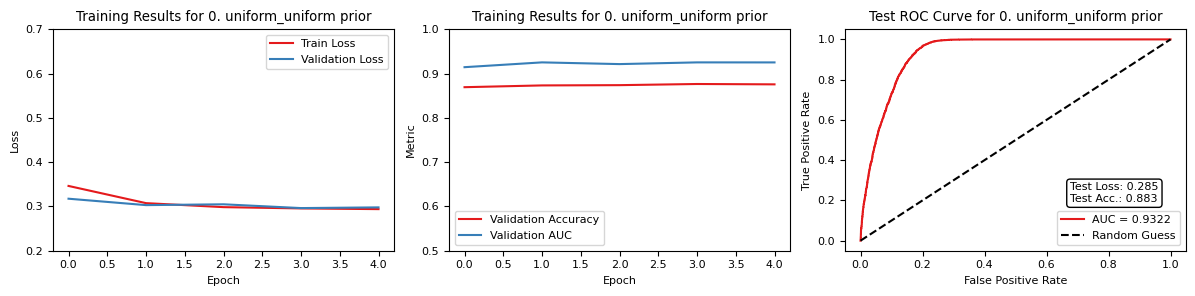

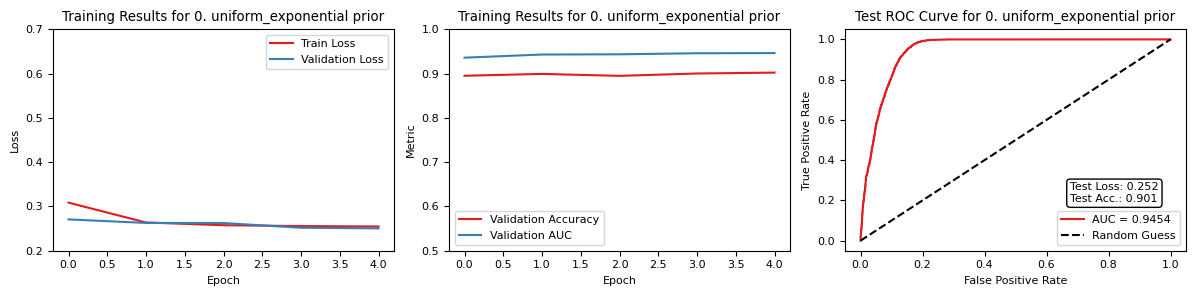

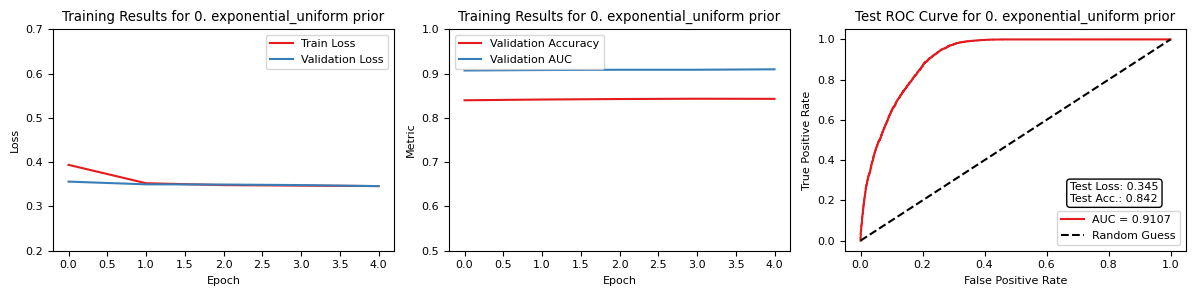

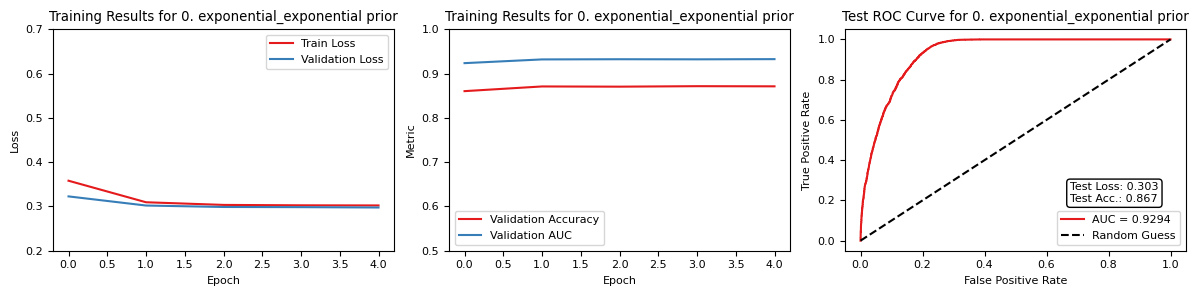

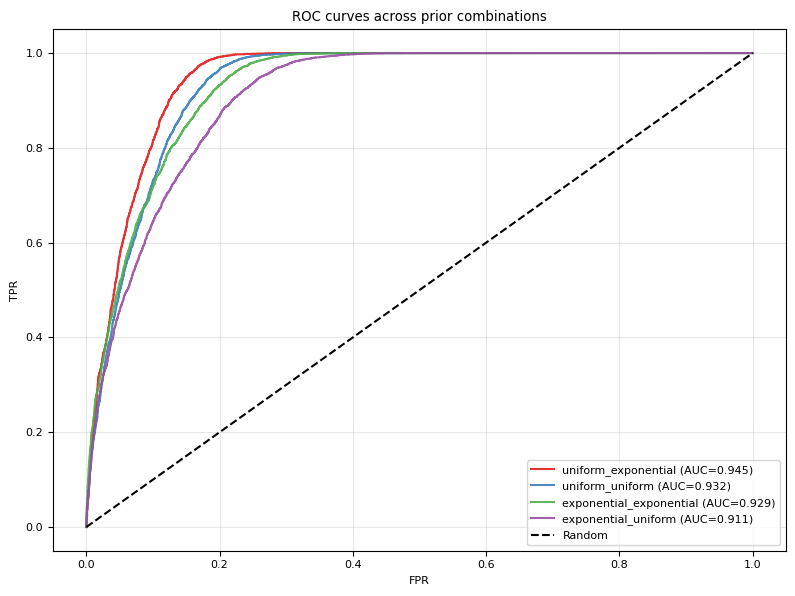

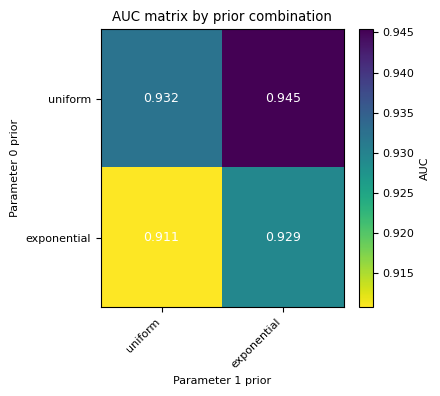

In [12]:
models = [{} for _ in range(config["training"]["model_iterations"])]
test_results = [{} for _ in range(config["training"]["model_iterations"])]
for prior0 in priors0:
    for prior1 in priors1:
        priors_names = f"{prior0.__name__}_{prior1.__name__}"
        for i in range(config["training"]["model_iterations"]):
            train_set, validation_set, test_set = get_data([prior0, prior1], config, show_output=False)
            model = BinaryClassifier(config)
            model, training_results = train(model, *train_set, *validation_set, show_output=False)
            filename_plots = get_filepath(f"training/training_{i}/training_{priors_names}_prior.svg", config)
            filename_model = get_filepath(f"models/models_{i}/model_{priors_names}_prior.pth", config)
            torch.save(model.state_dict(), filename_model)
            test_result = test_model(model, *test_set, show_output=False)
            plot_training_tests(training_results, test_result, f"{i}. {priors_names}", filename_plots)
            models[i][priors_names] = model
            test_results[i][priors_names] = test_result
plot_all_rocs(test_results, filename=get_filepath("training/all_roc_curves.svg", config))
plot_auc_matrix(test_results, priors0, priors1, filename=get_filepath("training/auc_matrix.svg", config))

#### Posterior:

In [13]:
def to_grid(arr, x_ranges):
    return arr.reshape([len(r) for r in x_ranges])

def integrate_nD(fct, x_range):
    """
    Perform numerical integration of a function over n dimensions using the trapezoidal rule.
    
    Parameters:
    - fct: n-dimensional array of function values at the grid points
    - x_range: list of numpy arrays, each produced by np.linspace for each dimension
    
    Returns:
    - Numerical integral of the function
    """
    
    result = fct
    # Integrate over each dimension, starting from the last
    for i in range(len(x_range) - 1, -1, -1):
        result = np.trapezoid(result, x_range[i], axis=i)
    
    return result

def create_inference_parameters(n_parameters_to_infer, parameters_min_max, margin=1/4, data_is_random=False):
    parameter_min, parameter_max = parameters_min_max
    parameter_range = parameter_max - parameter_min
    if data_is_random:
        parameters_to_infer = generator.uniform(
            low=parameter_min+parameter_range*margin,
            high=parameter_max-parameter_range*margin,
            size=n_parameters_to_infer
        )
    else:
        parameters_to_infer = np.linspace(parameter_min+parameter_range*margin, parameter_max-parameter_range*margin, n_parameters_to_infer)
    return parameters_to_infer

def create_inference_data(n_parameters_to_infer, parameters_min_max, margin=None, data_is_random=None, n_repititions_per_parameter=1, parameters_to_infer=None):
    n_priors = len(n_parameters_to_infer)
    if margin is None: margin = [1/4]*n_priors
    if data_is_random is None: data_is_random = [False]*n_priors
    if parameters_to_infer is None: parameters_to_infer = [None]*n_priors #shape=(n_priors, n_parameters_to_infer[i])
    
    for i in range(n_priors):
        if parameters_to_infer[i] is None: parameters_to_infer[i] = create_inference_parameters(n_parameters_to_infer[i], parameters_min_max[i], margin[i], data_is_random[i])
        
    #go through every combination of parameters_to_infer for each prior and draw n_repititions_per_parameter data points
    sampled_data = [] #shape=(n_parameter_combinations, n_repititions_per_parameter)
    parameter_combinations = list(itertools.product(*parameters_to_infer))
    for parameter_combination in parameter_combinations:
        sampled_data += [draw_data(n_repititions_per_parameter, *parameter_combination)]
    sampled_data = np.asarray(sampled_data)
    
    return parameters_to_infer, parameter_combinations, sampled_data

def area_above_k(k, x_range, posterior_normalized):
    """
    Compute the area where posterior >= k for n-dimensional distributions.
    
    Parameters:
    - k: threshold value
    - x_range: list of numpy arrays for each dimension
    - posterior_normalized: n-dimensional array of posterior values
    
    Returns:
    - Area (integral) above threshold k
    """
    mask = posterior_normalized >= k
    if not np.any(mask):
        return 0.0
    masked_posterior = np.where(mask, posterior_normalized, 0.0)
    area = integrate_nD(to_grid(masked_posterior, x_range), x_range)
    return area

def compute_hpd_interval(x_range, posterior_normalized, alpha):
    """
    Compute HPD interval for n-dimensional posterior distributions.
    
    Parameters:
    - x_range: list of numpy arrays for each dimension
    - posterior_normalized: n-dimensional array of posterior values
    - alpha: credible level (e.g., 0.32 for 68%, 0.05 for 95%)
    
    Returns:
    - List of intervals for each dimension [[dim0_low, dim0_high], [dim1_low, dim1_high], ...]
    """
    # Reshape to grid if posterior is 1D
    if posterior_normalized.ndim == 1:
        posterior_normalized = to_grid(posterior_normalized, x_range)
    
    def root_func(k):
        return area_above_k(k, x_range, posterior_normalized) - (1 - alpha)
    
    p_min = np.min(posterior_normalized)
    p_max = np.max(posterior_normalized)
    
    k_lower = p_min
    k_upper = p_max
    
    func_lower = root_func(k_lower)
    func_upper = root_func(k_upper)
    
    if func_lower < 0 or func_upper > 0:
        raise ValueError("Cannot find a valid k in the given range. Check the posterior and alpha.")
    
    k = brentq(root_func, k_lower, k_upper, xtol=1e-12)
    
    mask = posterior_normalized >= k
    
    # For each dimension, find the intervals where the marginalized mask is True
    n_dims = len(x_range)
    intervals_list = []
    
    for dim in range(n_dims):
        # Marginalize the mask over all other dimensions
        axes_to_reduce = tuple(i for i in range(n_dims) if i != dim)
        marginalized_mask = np.any(mask, axis=axes_to_reduce)
        
        indices = np.where(marginalized_mask)[0]
        theta = x_range[dim]
        
        intervals = []
        if indices.size > 0:
            breaks = np.where(np.diff(indices) > 1)[0]
            start_idx = 0
            breaks = np.append(breaks, len(indices) - 1)
            for break_idx in breaks:
                idx_range = indices[start_idx:break_idx + 1]
                theta_start = theta[idx_range[0]]
                theta_end = theta[idx_range[-1]]
                intervals.append([theta_start, theta_end])
                start_idx = break_idx + 1
        
        # Take the first interval (or empty) for each dimension
        if intervals:
            intervals_list.append(intervals[0])
        else:
            intervals_list.append([])
    
    return np.asarray(intervals_list)

def calculate_posterior(model, priors, data_point, all_parameters_in_range):
    all_parameters_in_grid = np.asarray(list(itertools.product(*all_parameters_in_range)))
    data_post = np.full(len(all_parameters_in_grid), data_point)
    input_post = torch.cat(
        tensors=[
            torch.tensor(data_post).float().to(device).unsqueeze(1),
            torch.tensor(all_parameters_in_grid).float().to(device)
        ],
        dim=1
    )
    model_out = model(input_post).cpu().detach().numpy().flatten()
    ratio = model_out / (1 - model_out)
    posterior = ratio * np.prod([prior(all_parameters_in_grid[:,i]) for i, prior in enumerate(priors)], axis=0) #prior(all_parameters_in_range)
    
    Z_post = integrate_nD(to_grid(posterior, all_parameters_in_range), all_parameters_in_range)
    Z_ratio = integrate_nD(to_grid(ratio, all_parameters_in_range), all_parameters_in_range)
    return posterior / Z_post, ratio / Z_ratio

def get_posteriors_and_errors(inference_data, all_parameters_in_range):
    # parameters_to_infer, sampled_data = inference_data
    parameters_to_infer, parameter_combinations, sampled_data = inference_data
    n_posterior_combinations, n_repititions_per_parameter = sampled_data.shape
    all_posteriors = {}
    all_HPDs = {}
    all_ratios = {}
    
    #for model, prior in zip(models[0], priors):
    total_iterations = n_posterior_combinations * n_repititions_per_parameter * len(priors0) * len(priors1)
    with tqdm(total=total_iterations, desc=f"Calculating posteriors and errors...") as pbar:
        for prior0 in priors0:
            for prior1 in priors1:
                prior_name = f"{prior0.__name__}_{prior1.__name__}"
                ratios_grouped, posteriors_grouped = [], []
                for i_posterior_combination in range(n_posterior_combinations):
                    posteriors_to_multipy, ratios_to_multiply = [], []
                    for i_posterior_repeat in range(n_repititions_per_parameter):
                        priors_names = f"{prior0.__name__}_{prior1.__name__}"
                        model = models[0][priors_names]
                        posterior, ratio = calculate_posterior(
                            model,
                            [prior0, prior1],
                            sampled_data[i_posterior_combination, i_posterior_repeat],
                            all_parameters_in_range
                        )
                        posteriors_to_multipy += [posterior]
                        ratios_to_multiply += [ratio]
                        pbar.update(1)
                    posterior_product = np.prod(posteriors_to_multipy, axis=0)
                    posterior_product /= integrate_nD(to_grid(posterior_product, all_parameters_in_range), all_parameters_in_range)
                    posteriors_grouped += [posterior_product]
                    ratio_product = np.prod(ratios_to_multiply, axis=0)
                    ratio_product /= integrate_nD(to_grid(ratio_product, all_parameters_in_range), all_parameters_in_range)
                    ratios_grouped += [ratio_product]
                errors = []
                for posterior in posteriors_grouped:
                    hpd_68 = compute_hpd_interval(
                        all_parameters_in_range,
                        posterior,
                        alpha=0.32
                    )
                    hpd_95 = compute_hpd_interval(
                        all_parameters_in_range,
                        posterior,
                        alpha=0.05
                    )
                    errors += [{"68": hpd_68, "95": hpd_95}]
                all_HPDs[prior_name] = errors
                all_posteriors[prior_name] = posteriors_grouped
                all_ratios[prior_name] = ratios_grouped
    return all_posteriors, all_HPDs, all_ratios

In [17]:
n_parameters=int(5e2)
parameters_min_max = [config["data"][f"parameter{i}_range"] for i in range(config["data"]["n_parameters"])]
all_parameters_in_range = [np.linspace(parameters_min_max[i][0], parameters_min_max[i][1], n_parameters) for i in range(len(parameters_min_max))]
inference_data = create_inference_data(n_parameters_to_infer=[4, 4], parameters_min_max=parameters_min_max, n_repititions_per_parameter=10)
all_posteriors, all_HPDs, all_ratios = get_posteriors_and_errors(inference_data, all_parameters_in_range)

Calculating posteriors and errors...: 100%|██████████| 640/640 [08:11<00:00,  1.30it/s]


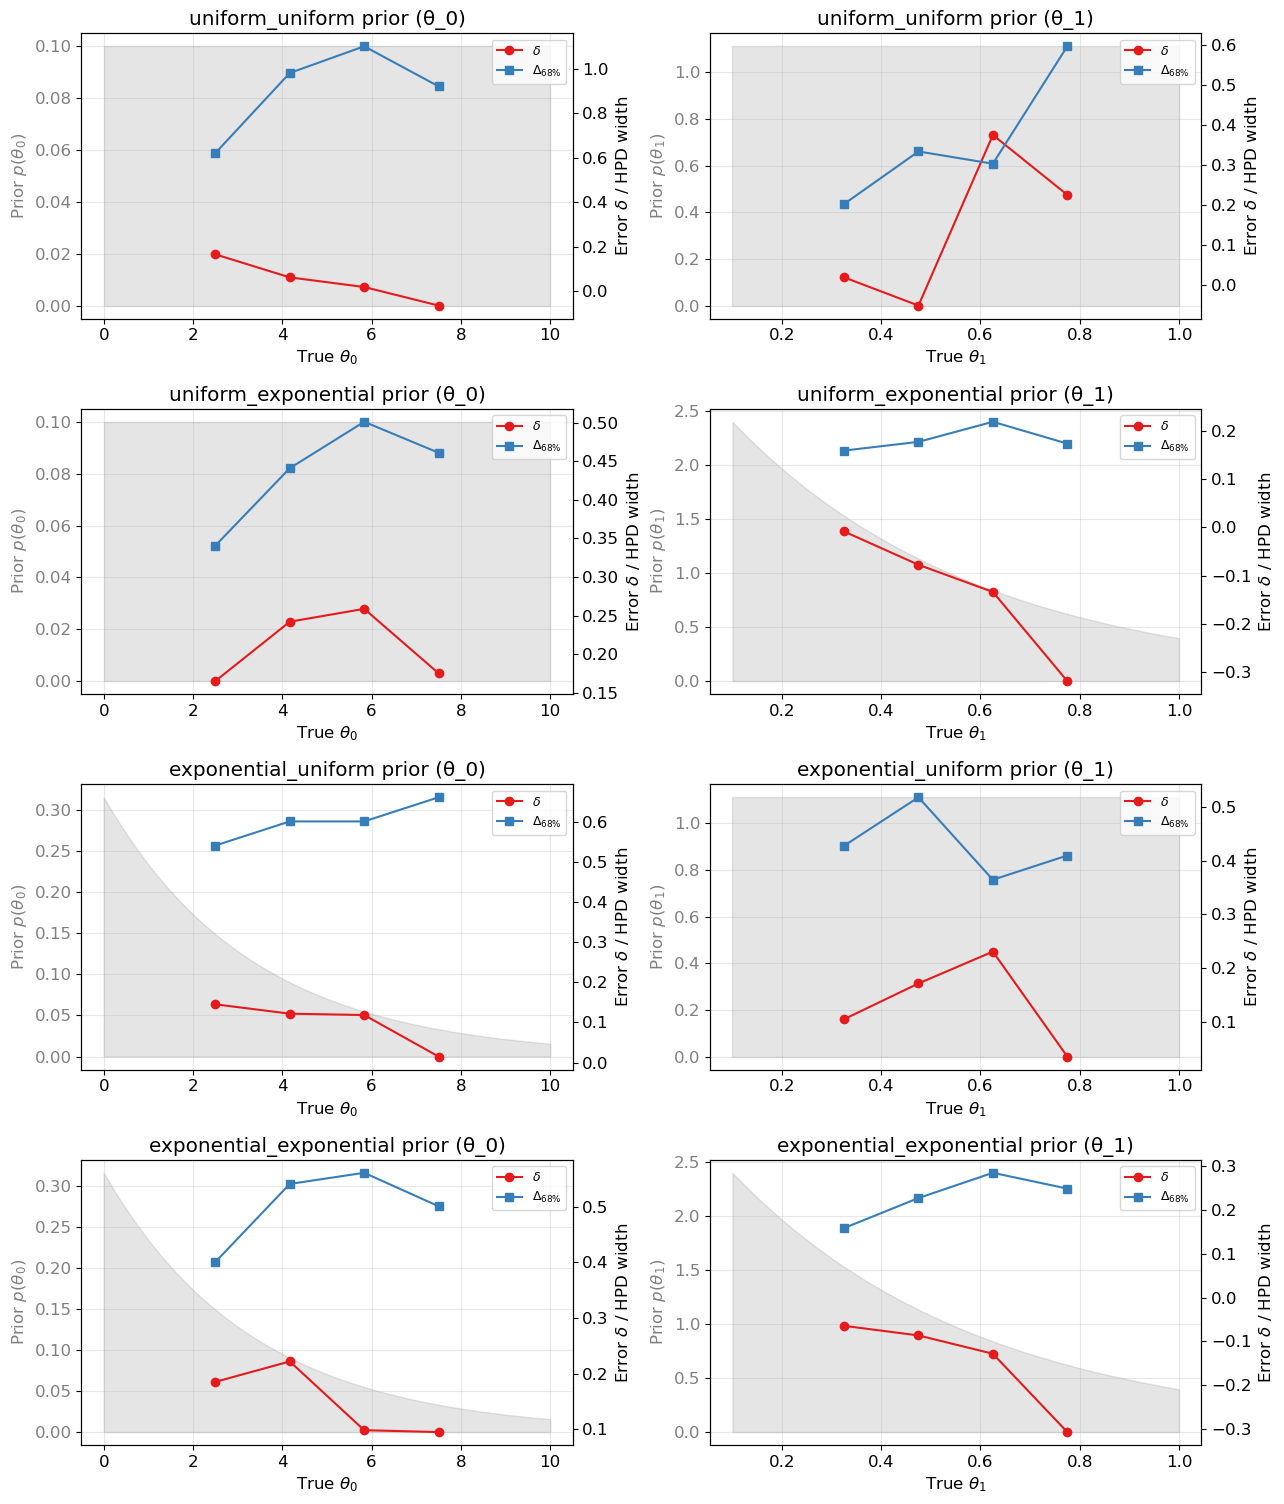

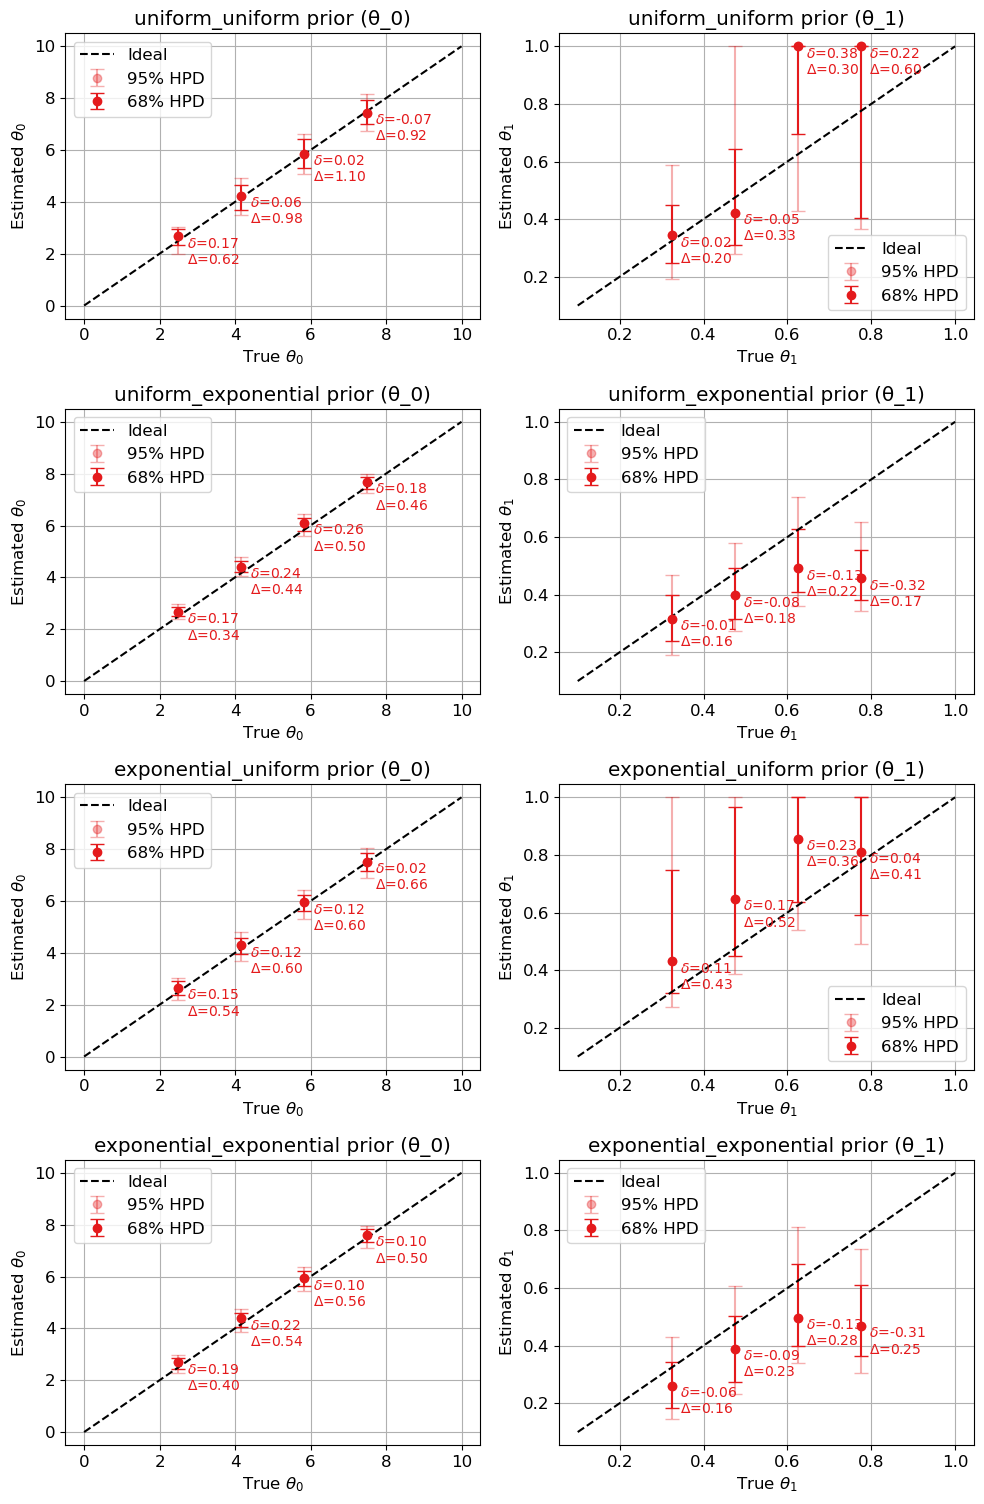

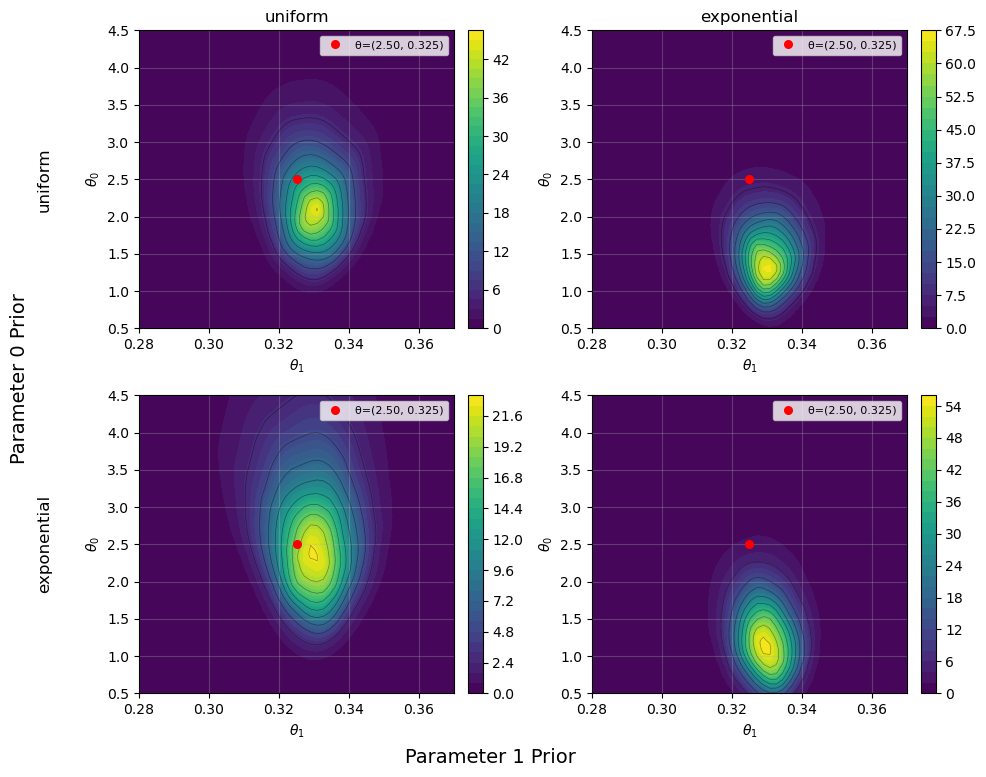

In [30]:
plot_error_and_hpd_width(all_HPDs, inference_data, all_posteriors, all_parameters_in_range, priors, filename=None)
plot_errorbars(all_HPDs, inference_data, all_posteriors, all_parameters_in_range, filename=None)
plot_all_posteriors_contour(all_posteriors, inference_data, priors0, priors1, all_parameters_in_range, filename=None)

Calculating posteriors and errors...: 100%|██████████| 160/160 [02:02<00:00,  1.30it/s]


Calculating posteriors and errors...: 100%|██████████| 160/160 [02:02<00:00,  1.30it/s]


IndexError: list index out of range

Calculating posteriors and errors...: 100%|██████████| 160/160 [02:02<00:00,  1.30it/s]


IndexError: list index out of range

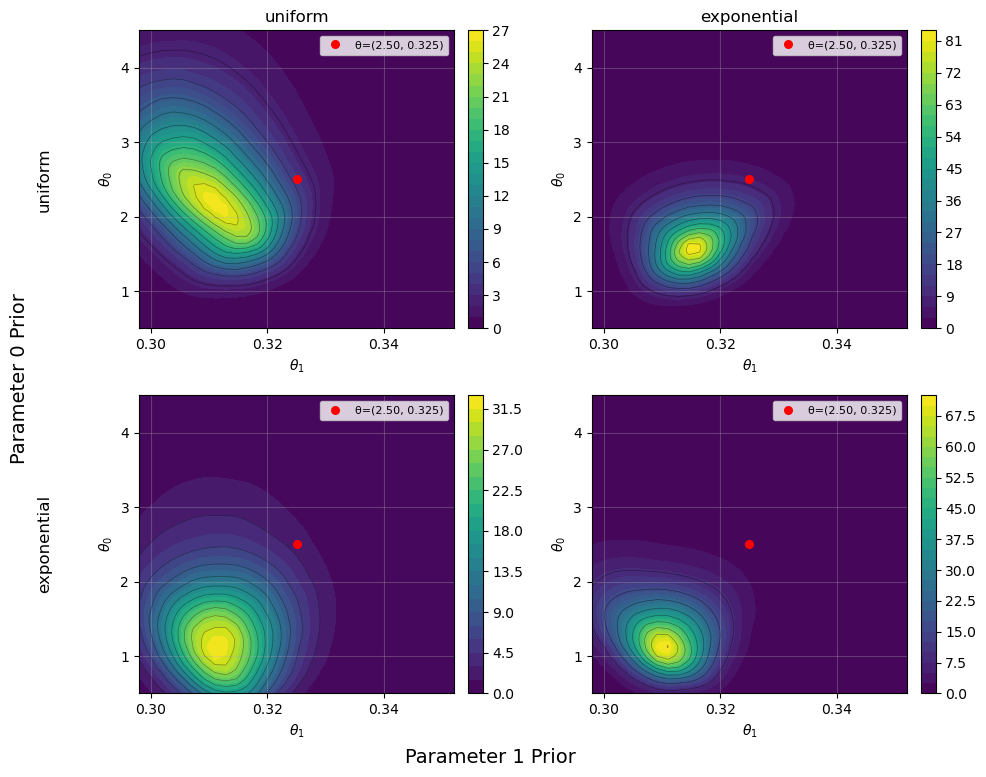

Calculating posteriors and errors...: 100%|██████████| 160/160 [02:02<00:00,  1.30it/s]


IndexError: list index out of range

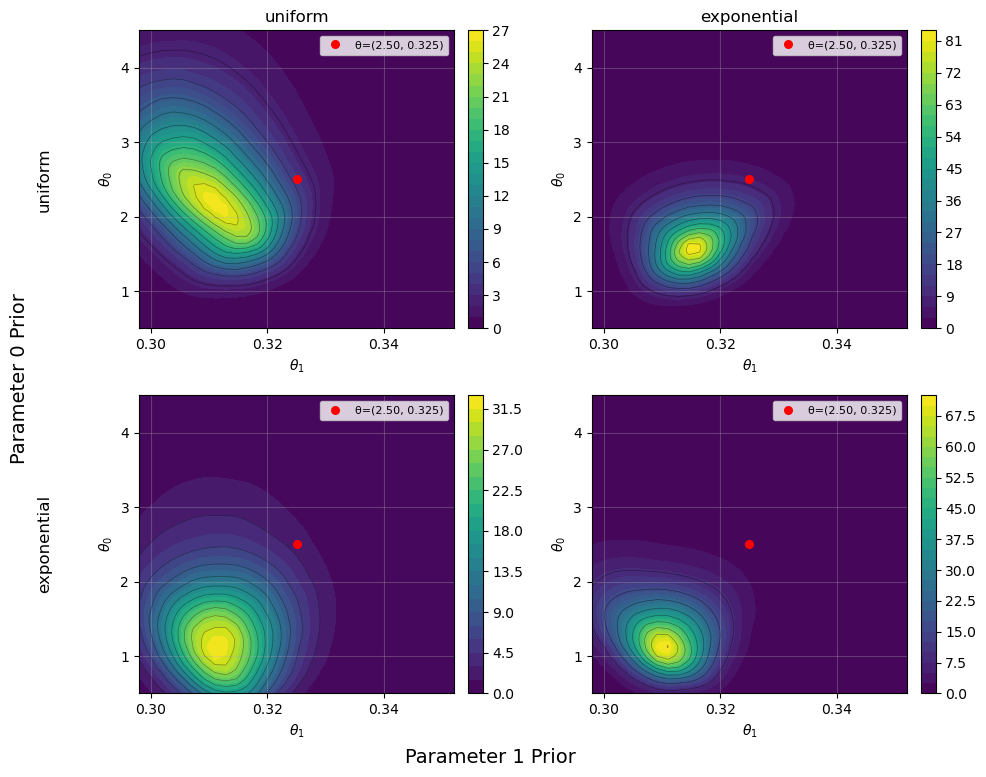

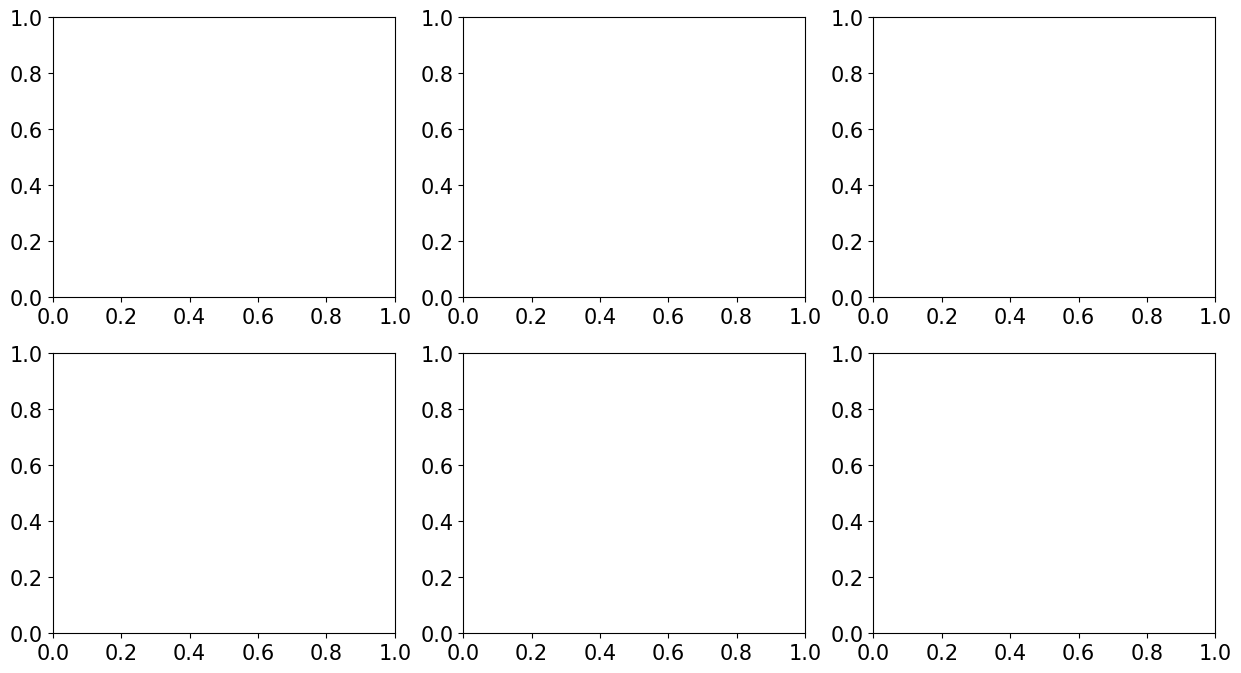

In [ ]:
save = True
n_repititions_per_parameter=10
n_parameters=int(5e2)

filename_parameter_per_prior = get_filepath(f"posterior_errors/parameter_per_prior.svg", config) if save else None
filename_prior_per_parameter = get_filepath(f"posterior_errors/prior_per_parameter.svg", config) if save else None
filename_prior_per_ratios = get_filepath(f"posterior_errors/prior_per_ratios.svg", config) if save else None
filename_errorbars = get_filepath(f"posterior_errors/errorbars.svg", config) if save else None
filename_error_and_hpd_width = get_filepath(f"posterior_errors/error_and_hpd_width.svg", config) if save else None
filename_error_and_hpd_width_ratios = get_filepath(f"posterior_errors/error_and_hpd_width_ratios.svg", config) if save else None

parameters_min_max = [config["data"][f"parameter{i}_range"] for i in range(config["data"]["n_parameters"])]
all_parameters_in_range = [np.linspace(parameters_min_max[i][0], parameters_min_max[i][1], n_parameters) for i in range(len(parameters_min_max))]
inference_data = create_inference_data(n_parameters_to_infer=[2, 2], parameters_min_max=parameters_min_max, n_repititions_per_parameter=10)
all_posteriors, all_HPDs, all_ratios = get_posteriors_and_errors(inference_data, all_parameters_in_range)
plot_all_posteriors_contour(all_posteriors, inference_data, priors0, priors1, all_parameters_in_range, zoom_factor=(.2, .03),filename=None)
plot_errorbars(all_HPDs, inference_data, all_posteriors, all_parameters_in_range, filename=None)

inference_data = create_inference_data(n_posterior=50, margin=0, samples_per_n_posterior=n_repititions_per_parameter)
all_posteriors, all_HPDs, all_ratios = get_posteriors_and_errors(inference_data, all_parameters_in_range)
plot_error_and_hpd_width(all_HPDs, inference_data, all_posteriors, all_parameters_in_range, priors, filename=None)

Calculating posteriors and errors...: 100%|██████████| 1440/1440 [18:41<00:00,  1.28it/s]


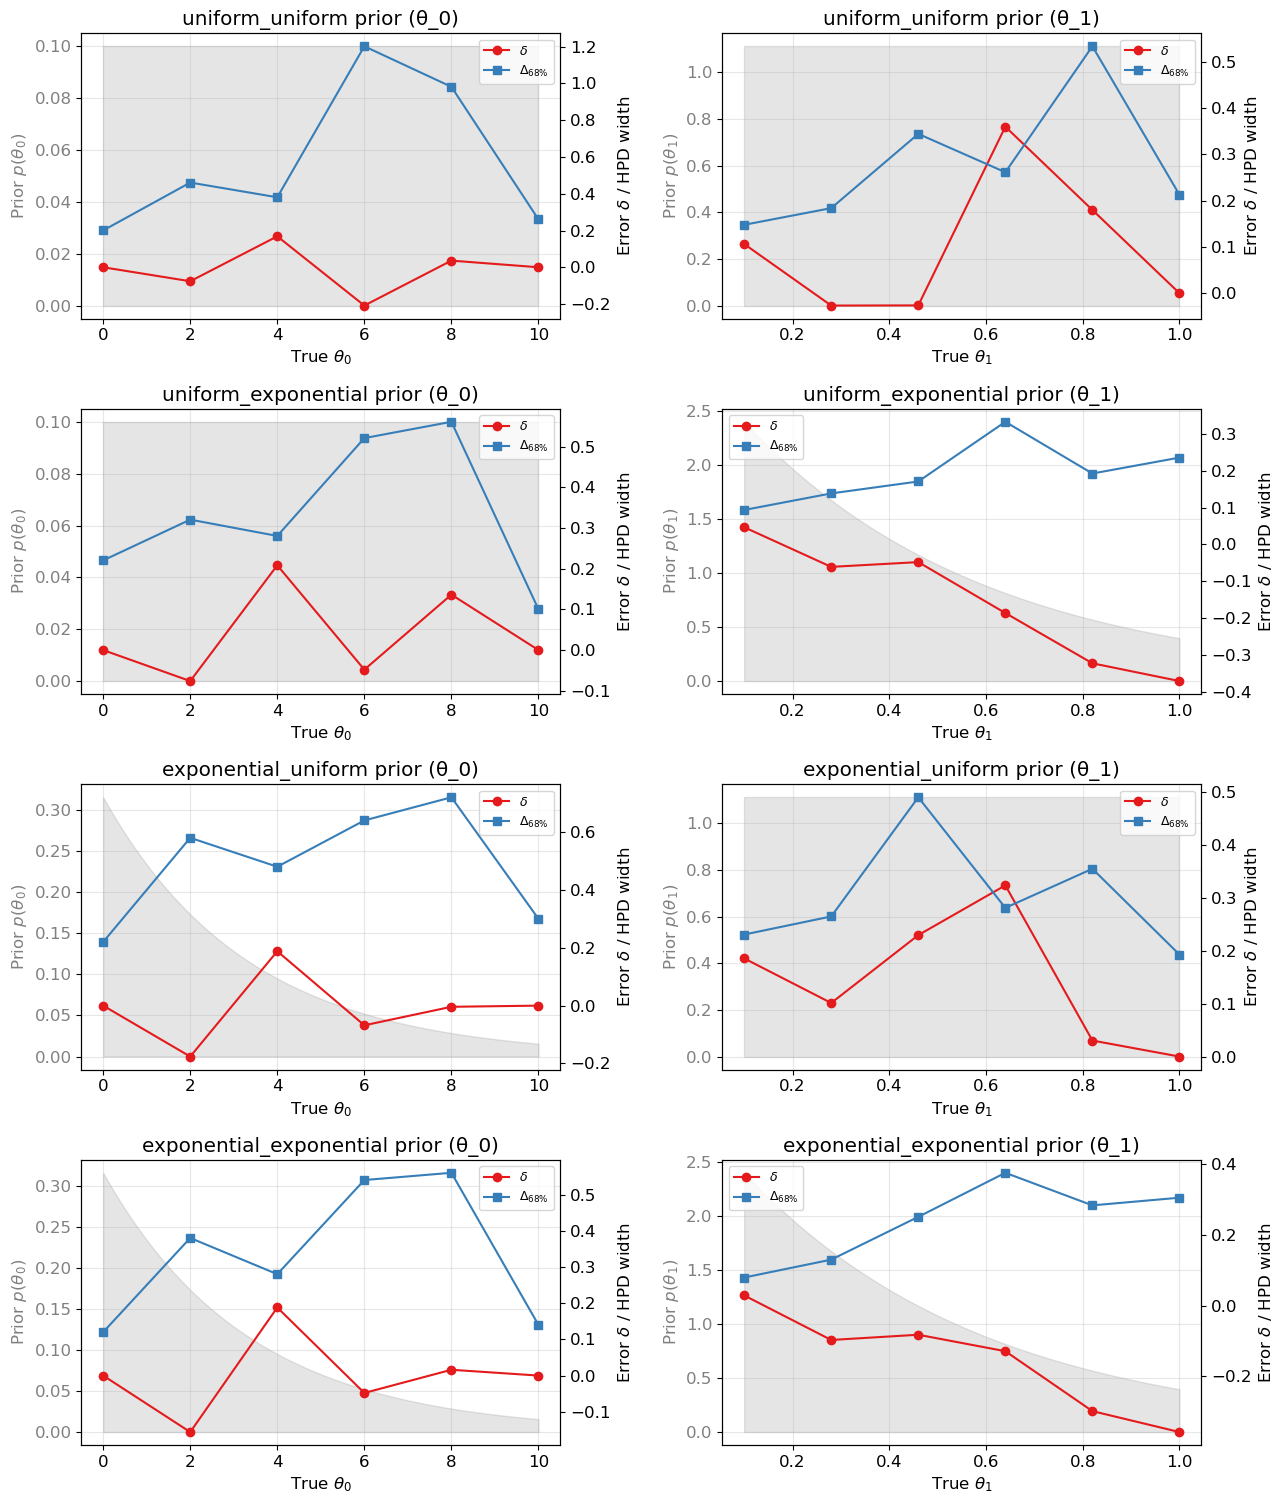

In [ ]:
save = True
n_repititions_per_parameter=10
parameters_min_max = [config["data"][f"parameter{i}_range"] for i in range(config["data"]["n_parameters"])]
all_parameters_in_range = [np.linspace(parameters_min_max[i][0], parameters_min_max[i][1], n_parameters) for i in range(len(parameters_min_max))]
inference_data = create_inference_data(n_parameters_to_infer=[6, 6], parameters_min_max=parameters_min_max, margin=[0, 0], n_repititions_per_parameter=10)
all_posteriors, all_HPDs, all_ratios = get_posteriors_and_errors(inference_data, all_parameters_in_range)
plot_error_and_hpd_width(all_HPDs, inference_data, all_posteriors, all_parameters_in_range, priors, filename=filename_error_and_hpd_width)
plot_error_and_hpd_width(all_HPDs, inference_data, all_ratios, all_parameters_in_range, priors, filename=filename_error_and_hpd_width_ratios)

#### Posterior Checks:

Check I: ratio expectation value

$1=\int p(x|\theta_0) dx = \int r(x|\theta_0) p(x) dx = \mathbb{E} [r(x|\theta_0)]$

i.e. if $\mathbb{E} [r(x|\theta_0)]=1$, then $r(x|\theta_0) = p(x|\theta_0) / p(x) = p(\theta_0 | x) / p(\theta_0)$ is plausible

In [ ]:
def calculate_individual_ratios(data, parameter):
    _, data_inputs = data
    parameters = parameter
    if isinstance(parameter, float) or isinstance(parameter, int):
        parameters = np.full(len(data_inputs), parameter)
    ratios = {}
    for model, prior in zip(models[0], priors):
        ratios_per_model = []
        for data_fixed, parameter_fixed in zip(data_inputs, parameters):
            input_post = torch.cat(
                tensors=[torch.tensor([x]).float().to(device).unsqueeze(1) for x in (data_fixed, parameter_fixed)],
                dim=1
            )
            model_out = model(input_post).cpu().detach().numpy().flatten()
            ratio = model_out / (1 - model_out)
            ratios_per_model += [ratio[0]]
        ratios[prior.__name__] = ratios_per_model
    return ratios

def calculate_all_ratios(data_inputs, test_parameters):
    all_ratios = {}
    for parameter in test_parameters:
        ratios = calculate_individual_ratios(data_inputs, parameter)
        for prior_name, ratio_values in ratios.items():
            if prior_name not in all_ratios:
                all_ratios[prior_name] = []
            all_ratios[prior_name] += [ratio_values]
    return all_ratios

In [ ]:
inference_data = create_inference_data(n_posterior=1000, margin=0, data_is_random=True, samples_per_n_posterior=1)
test_parameters = np.linspace(parameter_min, parameter_max, 5)
all_ratios = calculate_all_ratios(inference_data, test_parameters)

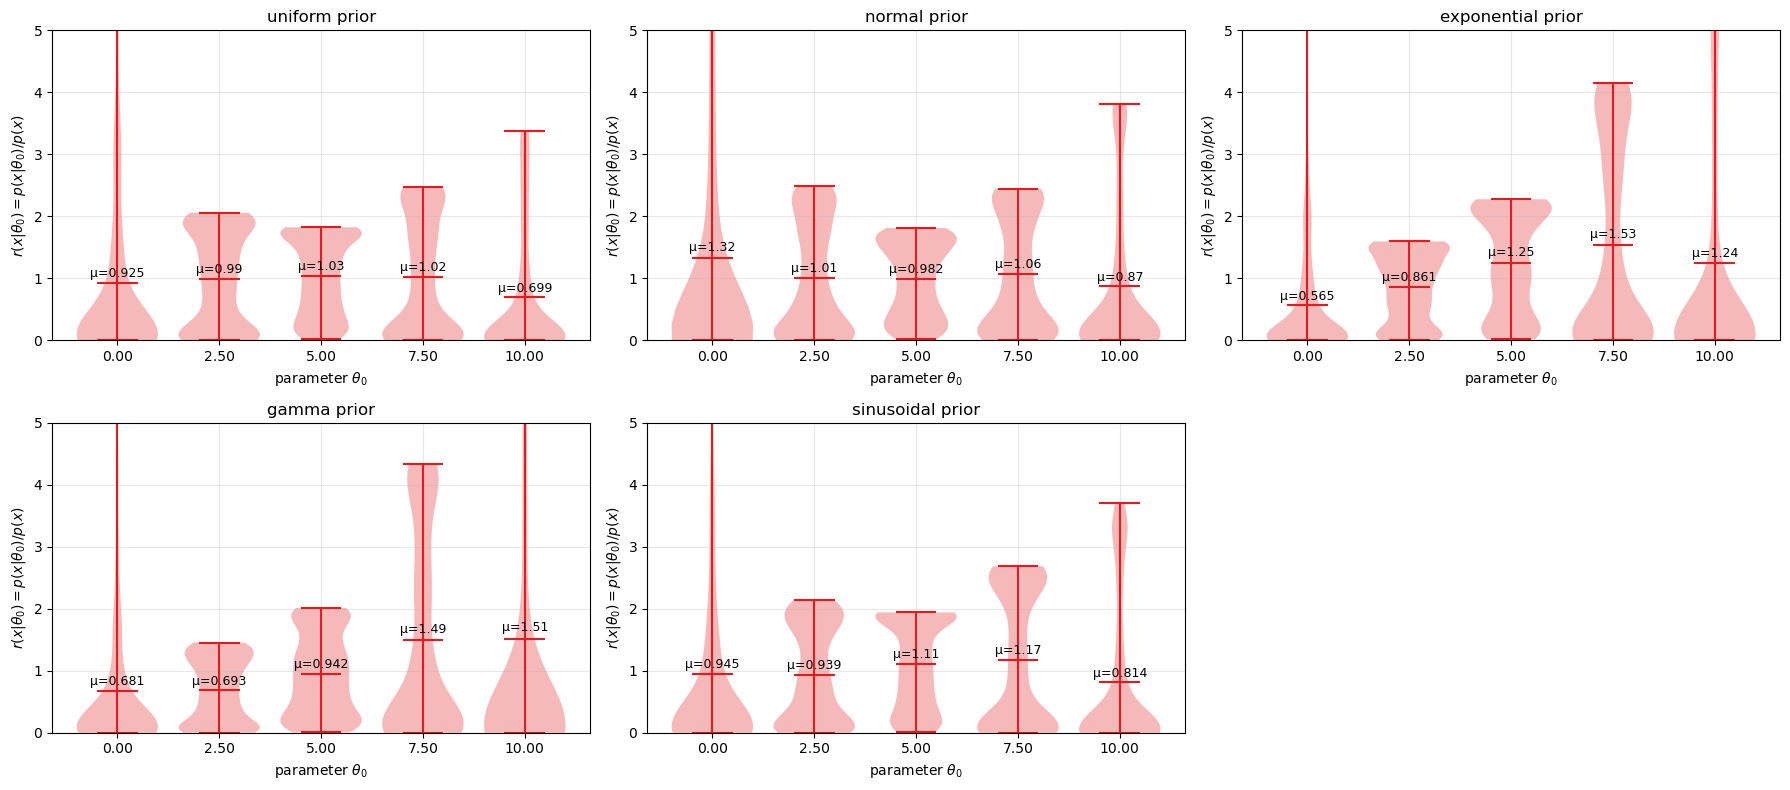

In [15]:
filename_ratio_violins = get_filepath(f"verifications/ratio_violins.svg", config) if save else None
plot_ratio_violins(all_ratios, test_parameters, filename=filename_ratio_violins)

Check II: reweighting

$R_{10}(x) = \frac{r(x|\theta_1)}{r(x|\theta_0)} = \frac{p(x|\theta_1)}{p(x|\theta_0)}$

if $p(x|\theta_1) = R_{10}(x)p(x|\theta_0)$: likelihood ratio trick holds

In [16]:
def compute_ratio(data, parameter, model):
    def _to_array_or_scalar(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        if np.isscalar(x):
            return x, 'scalar'
        x = np.asarray(x)
        assert x.ndim == 1, "Expected 1D input when passing an array-like."
        return x, 'vector'

    data_point, _t_data = _to_array_or_scalar(data)
    parameters, _t_param = _to_array_or_scalar(parameter)

    if _t_data == 'scalar' and _t_param == 'vector':
        data_point = np.full(parameters.shape, data_point, dtype=float)
    elif _t_data == 'vector' and _t_param == 'scalar':
        parameters = np.full(data_point.shape, parameters, dtype=float)
    elif _t_data == 'vector' and _t_param == 'vector':
        assert len(data_point) == len(parameters), "data and parameter must have the same length."
    elif _t_data == 'scalar' and _t_param == 'scalar':
        data_point = [data_point]
        parameters = [parameter]
    
    model_in = torch.cat(
        tensors=[torch.tensor(x).float().to(device).unsqueeze(1) for x in (data_point, parameters)],
        dim=1
    )
    model_out = model(model_in).cpu().detach().numpy().flatten()
    ratio = model_out / (1 - model_out)
    return ratio, model_out

def reweight_distributions(test_parameters, model_arr, n_test_data=int(1e6), n_bins=int(1e3)):
    all_ratios = {}
    all_outs = {}
    reweighting_distributions = {}
    reweighted_distributions = {}
    data_x = [generator.normal(loc=parameter, scale=config["data"]["std"], size=n_test_data) for parameter in test_parameters]
    for prior, model in zip(priors, model_arr):
        results = [compute_ratio(data_x[0], parameter, model) for parameter in test_parameters]
        ratios = [result[0] for result in results]
        model_outs = [result[1] for result in results]
        all_ratios[prior.__name__] = ratios
        all_outs[prior.__name__] = model_outs
        reweighting_distributions[prior.__name__] = ratios[1] / ratios[0]
        reweighted_distribution, edges = np.histogram(
            data_x[0],
            bins=n_bins,
            weights=reweighting_distributions[prior.__name__],
            density=False,
            #range=config["data"]["parameter_range"]
        )
        bin_centers = 0.5 * (edges[:-1] + edges[1:])
        reweighted_distributions[prior.__name__] = (bin_centers, reweighted_distribution)
    return data_x, reweighted_distributions, reweighting_distributions, all_outs

In [18]:
n_test_data = int(1e7)
n_bins = int(1e3)
test_parameters = [(3, 7)] #, (7, 8), (4, 7), (6, 4)]
for i, model_arr in enumerate(models):
    for test_parameter_set in test_parameters:
        data_x, reweighted_distributions, reweighting_distributions, all_outs = reweight_distributions(test_parameter_set, model_arr, n_test_data, n_bins)
        filename_overlap_integrals = get_filepath(f"verifications/reweighting_{i}/overlap_integrals_{test_parameter_set[0]}_{test_parameter_set[1]}.svg", config) if save else None
        filename_reweighted_distributions = get_filepath(f"verifications/reweighting_{i}/reweighted_distributions_{test_parameter_set[0]}_{test_parameter_set[1]}.svg", config) if save else None
        #plot_overlap_integrals_per_prior(data_x, reweighting_distributions, priors, n_bins, filename=filename_overlap_integrals)
        plot_reweighted_distributions(priors, data_x, reweighted_distributions, test_parameter_set, n_bins, filename=filename_reweighted_distributions)
        #plot_all_outs_histograms(all_outs, test_parameter_set, n_bins=50, filename=None)

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.38 GiB. GPU 0 has a total capacity of 10.57 GiB of which 521.00 MiB is free. Process 794040 has 3.87 GiB memory in use. Process 1286439 has 660.00 MiB memory in use. Including non-PyTorch memory, this process has 5.14 GiB memory in use. Of the allocated memory 4.93 GiB is allocated by PyTorch, and 8.66 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)